# Paper's Pipeline

In [46]:
import os
import pickle
import warnings

import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import pearsonr, beta as _beta_dist

from leaspy.io.data import Data
from leaspy.models import JointModel
from leaspy.datasets import load_dataset

warnings.filterwarnings("ignore", category=UserWarning)

## Reference model (source of true $\theta$)

The reference model is fitted once on the original data. Its parameters play the role of **true $\theta$** for the
simulation study, every simulated dataset will be generated from this model.

In [47]:
M          = 20 # Number of simulations per condition
N          = 1000 # Number of samples per simulation 
N_ITER     = 5000   
N_PERSO    = 5000   
NB_EVENTS  = 1

In [48]:
visit_params = {
    "patient_number": N,
    "visit_type": "random",
    "first_visit_mean": -2.0,
    "first_visit_std":  1.0,
    "time_follow_up_mean": 6.0,
    "time_follow_up_std":  2.0,
    "distance_visit_mean": 0.083 * 3,
    "distance_visit_std":  0.042,
    "min_spacing_between_visits": 0.05,
} 
# WARNING: these parameters are not based on real data, but typically overestimate the number of visits 
# per patient to get more data points, which lead to less iterations needed to get stable results. 


In [49]:
REF_MODEL_PATH = os.path.join("..", "models", "PROACT_multivariate.json")
ref_model = JointModel.load(REF_MODEL_PATH)

FEATURES  = ref_model.features
SAVE_PATH = os.path.join("..", "output", "PROACT_multivariate_N=1000_M=200_Niter=70000_Nperso=5000.pkl")

# Extract observation model configuration from reference model
obs_model_y = ref_model.obs_models[0]
obs_model_name = obs_model_y.to_string()
print(f"Reference model observation model: {obs_model_name}")

theta_true = {
    k: v.detach().cpu().numpy().copy()
    for k, v in ref_model.parameters.items()
}

print("True parameters theta (reference model):")
for k, v in theta_true.items():
    print(f"  {k:25s}: {np.atleast_1d(v).tolist()}")

Reference model observation model: gaussian-diagonal
True parameters theta (reference model):
  betas_mean               : [[0.015447118319571018, -0.21185511350631714], [-0.23175998032093048, -0.04968435317277908], [-0.019070692360401154, -0.008649973198771477]]
  log_g_mean               : [2.347646951675415, 0.8443127274513245, 0.6683555841445923, 1.2280733585357666]
  log_rho_mean             : [0.6148523092269897]
  log_v0_mean              : [-2.557422637939453, -1.3578702211380005, -1.4338750839233398, -2.020606279373169]
  n_log_nu_mean            : [-1.3980814218521118]
  noise_std                : [0.0686509981751442, 0.07857546955347061, 0.07428897172212601, 0.04472038149833679]
  tau_mean                 : [56.69894790649414]
  tau_std                  : [11.629801750183105]
  xi_std                   : [1.0783039331436157]
  zeta_mean                : [[-0.13000449538230896], [0.2804334759712219]]


## Simulation study loop

For each repetition m = 1, …, M:
1. Simulate a dataset of N patients from the reference model.
2. Fit a fresh `JointModel` on this simulated dataset.
3. Personalise to recover individual parameters.

In [50]:
from IPython.utils import io

with io.capture_output() as captured:
    if os.path.exists(SAVE_PATH):
        with open(SAVE_PATH, "rb") as f:
            results = pickle.load(f)
        # backward-compat: older pickles may not have ref_ips
        if "ref_ips" not in results:
            results["ref_ips"] = [None] * len(results["pop_params"])
        print(f"Loaded {len(results['pop_params'])} results from {SAVE_PATH}")
    else:
        results = {
            "pop_params": [],   # list of M dicts {param_name: np.ndarray}
            "true_ips":   [],   # list of M DataFrames with columns xi, tau (from simulation)
            "ref_ips":    [],   # list of M DataFrames: ref_model personalised on sim_data (oracle)
            "est_ips":    [],   # list of M DataFrames with columns xi, tau (from personalisation with new_model)
        }

        # Number of digits needed so zero-padded IDs sort lexicographically == numerically.
        # e.g. N=50 → 2 digits: "00","01",...,"49"  (avoids "0","1","10","11",... ordering)
        _n_digits = len(str(N - 1))

        for m in tqdm(range(M), desc="Simulation study"):

            # Simulate a dataset with the reference model
            np.random.seed(m)
            torch.manual_seed(m)

            sim_result = ref_model.simulate(
                algorithm="joint_simulate",
                features=FEATURES,
                visit_parameters=visit_params,
            )
            sim_data = sim_result.data

            # Rename IDs to zero-padded strings so that groupby("ID").min() inside
            # JointModel's Weibull initialisation produces the same patient order as
            # dataset.event_time (which uses insertion order).
            _df_sim = sim_data.to_dataframe()
            _id_map = {old: old.zfill(_n_digits) for old in _df_sim["ID"].unique()}
            _df_sim["ID"] = _df_sim["ID"].map(_id_map)
            sim_data = Data.from_dataframe(_df_sim, "joint", factory_kws={"nb_events": NB_EVENTS})

            # individual_parameters from simulate is a DataFrame [xi, tau, ...]
            ip_sim = sim_result.individual_parameters
            true_ip_df = ip_sim if isinstance(ip_sim, pd.DataFrame) else pd.DataFrame(ip_sim)
            true_ip_df.index = true_ip_df.index.map(lambda x: x.zfill(_n_digits))

            # Oracle: personalise with the TRUE reference model (known θ).
            # Computed here (only needs ref_model), but appended to results below
            # alongside true_ips/est_ips to keep all lists in sync.
            ref_ip_df = None
            try:
                ref_ip = ref_model.personalize(
                    sim_data, "mean_posterior",
                    seed=3000 + m, n_iter=N_PERSO, progress_bar=False,
                )
                ref_ip_df = ref_ip.to_dataframe()
            except Exception as exc:
                print(f"  [m={m}] Oracle personalisation failed: {exc}")

            # Fit a new model on the simulated data to recover population parameters
            # Use the same observation model as the reference model
            new_model = JointModel(
                name=f"m{m}",
                nb_events=NB_EVENTS,
                dimension=ref_model.dimension,
                source_dimension=ref_model.source_dimension,
                obs_models=obs_model_name,
            )
            try:
                new_model.fit(
                    sim_data, "mcmc_saem",
                    seed=1000 + m, n_iter=N_ITER, progress_bar=False,
                )
            except Exception as exc:
                print(f"  [m={m}] Fit failed: {exc}")
                continue   # ref_ip_df not yet appended — all lists stay in sync
            est_params = {
                k: v.detach().cpu().numpy().copy()
                for k, v in new_model.parameters.items()
            }
            results["pop_params"].append(est_params)

            # Personalise the new model to recover individual parameters.
            # ref_ips is appended here (same place as true_ips / est_ips) so all
            # four lists always have the same length.
            try:
                est_ip = new_model.personalize(
                    sim_data, "mean_posterior",
                    seed=2000 + m, n_iter=N_PERSO, progress_bar=False,
                )
                results["est_ips"].append(est_ip.to_dataframe())
                results["true_ips"].append(true_ip_df)
                results["ref_ips"].append(ref_ip_df)
            except Exception as exc:
                print(f"  [m={m}] Personalisation failed: {exc}")
                results["est_ips"].append(None)
                results["true_ips"].append(None)
                results["ref_ips"].append(ref_ip_df)

        with open(SAVE_PATH, "wb") as f:
            pickle.dump(results, f)
        print(f"Results saved to {SAVE_PATH}")

## Model parameter metrics (RB, RRMSE, REE, RSE)

$$
REE(m) = \frac{\hat{\theta}^{(m)}-\theta}{\theta} \times 100 \qquad
RB(\hat\theta) = \frac{1}{M}\sum_m REE(m) \qquad
RRMSE(\hat\theta) = \sqrt{\frac{1}{M}\sum_m REE(m)^2}
$$

$$
SE_{emp}(\hat\theta) = \sqrt{\frac{\sum_m(\hat\theta^{(m)}-\bar{\hat\theta})^2}{M-1}}
\qquad
RSE_{emp}(\hat\theta) = \frac{SE_{emp}(\hat\theta)}{\bar{\hat\theta}}
$$

In [51]:
def clopper_pearson_ci(k, n, alpha=0.05):
    """Exact Clopper-Pearson CI for a binomial proportion k/n."""
    lo = _beta_dist.ppf(alpha / 2,     k,     n - k + 1) if k > 0 else 0.0
    hi = _beta_dist.ppf(1 - alpha / 2, k + 1, n - k    ) if k < n else 1.0
    return lo, hi


def _bootstrap_metric_cis(theta_true_val, theta_hats, n_boot=2000, alpha=0.05, seed=1234):
    theta_hats = np.asarray(theta_hats, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(theta_hats)

    rb_boot = []
    rrmse_boot = []
    rse_boot = []

    for _ in range(n_boot):
        sample = rng.choice(theta_hats, size=n, replace=True)
        ree = (sample - theta_true_val) / abs(theta_true_val) * 100
        rb_boot.append(ree.mean())
        rrmse_boot.append(np.sqrt((ree ** 2).mean()))
        rse_boot.append(sample.std(ddof=1) / abs(sample.mean()))

    q_lo = 100 * alpha / 2
    q_hi = 100 * (1 - alpha / 2)

    return {
        "RB_lo": float(np.percentile(rb_boot, q_lo)),
        "RB_hi": float(np.percentile(rb_boot, q_hi)),
        "RRMSE_lo": float(np.percentile(rrmse_boot, q_lo)),
        "RRMSE_hi": float(np.percentile(rrmse_boot, q_hi)),
        "RSE_lo": float(np.percentile(rse_boot, q_lo)),
        "RSE_hi": float(np.percentile(rse_boot, q_hi)),
    }


def compute_metrics(theta_true_val, theta_hats, se_hats=None, n_boot=2000, alpha=0.05, seed=1234):
    """
    Compute RB, RRMSE and RSE for a scalar estimand.
    Adds bootstrap CIs for RB/RRMSE/RSE.
    Optionally computes coverage rate (CR) with exact Clopper-Pearson CI.
    """
    theta_hats = np.asarray(theta_hats, dtype=float)

    ree    = (theta_hats - theta_true_val) / abs(theta_true_val) * 100
    rb     = float(ree.mean())
    rrmse  = float(np.sqrt((ree ** 2).mean()))
    se_emp = float(theta_hats.std(ddof=1))
    rse    = float(se_emp / abs(theta_hats.mean()))

    out = {"REE": ree, "RB": rb, "RRMSE": rrmse, "RSE": rse}
    out.update(_bootstrap_metric_cis(theta_true_val, theta_hats, n_boot=n_boot, alpha=alpha, seed=seed))

    if se_hats is not None:
        se_hats = np.asarray(se_hats, dtype=float)
        covered = (
            (theta_hats - 1.96 * se_hats <= theta_true_val) &
            (theta_true_val <= theta_hats + 1.96 * se_hats)
        )
        k = int(covered.sum())
        lo, hi = clopper_pearson_ci(k, len(theta_hats), alpha=alpha)
        out.update({"CR": k / len(theta_hats), "CR_lo": lo, "CR_hi": hi})

    return out

In [52]:
PARAM_LABELS = {
    "xi_std":        r"$\sigma_{\xi}$",
    "tau_mean":      r"$t_0$",
    "tau_std":       r"$\sigma_{\tau}$",
    "noise_std":     r"$\sigma$",
    "g":             r"$\tilde{g}$",
    "log_v0":        r"$\tilde{v}_0$",
    "n_log_nu_mean": r"$\tilde{\nu}$",
    "log_rho_mean":  r"$\tilde{\rho}$",
    "log_g_mean":    r"$\tilde{g}$",
    "log_v0_mean":   r"$\tilde{v}_0$",
}

LOG_PARAM_TRANSFORMS = {
    "log_v0":        (np.exp,               r"$v_0$"),
    "n_log_nu_mean": (lambda x: np.exp(-x), r"$\nu$"),
    "log_rho_mean":  (np.exp,               r"$\rho$"),
    "log_g_mean":    (np.exp,               r"$g$"),
    "log_v0_mean":   (np.exp,               r"$v_0$"),
}

def component_label(base_label, idx, size):
    if size == 1:
        return base_label
    if isinstance(base_label, str) and base_label.startswith("$") and base_label.endswith("$"):
        return f"{base_label[:-1]}^{{({idx})}}$"
    return f"{base_label} ({idx})"


# betas_mean and zeta_mean are rotationally non-identifiable - skip entirely.
NON_IDENTIFIABLE_PARAMS = {"betas_mean", "zeta_mean"}

summary_rows = []
ree_dict     = {}
ree_groups   = {}  # {param_name: {label: ree_array}}

for param_name, theta_true_arr in theta_true.items():
    if param_name in NON_IDENTIFIABLE_PARAMS:
        continue

    theta_true_flat = np.atleast_1d(np.array(theta_true_arr).ravel())

    hats_list = [
        np.atleast_1d(np.array(r[param_name]).ravel())
        for r in results["pop_params"]
        if r is not None and param_name in r
    ]
    if not hats_list:
        continue
    hats_mat = np.array(hats_list, dtype=float)  # (M_actual, d)

    if param_name in LOG_PARAM_TRANSFORMS:
        transform, nat_label_base = LOG_PARAM_TRANSFORMS[param_name]
        log_label_base = PARAM_LABELS.get(param_name, param_name)

        theta_nat_flat = np.atleast_1d(transform(theta_true_flat))
        hats_nat_mat   = np.atleast_2d(transform(hats_mat))

        for j, (t_nat, t_log) in enumerate(zip(theta_nat_flat, theta_true_flat)):
            t_nat = float(t_nat)
            t_log = float(t_log)
            if abs(t_nat) < 1e-10 or abs(t_log) < 1e-10:
                continue

            hat_vec_nat = hats_nat_mat[:, j]
            hat_vec_log = hats_mat[:, j]
            table_label = component_label(nat_label_base, j, len(theta_nat_flat))
            plot_label  = component_label(log_label_base, j, len(theta_nat_flat))

            mets         = compute_metrics(t_nat, hat_vec_nat)
            ree_for_plot = (hat_vec_log - t_log) / abs(t_log) * 100

            summary_rows.append({
                "Parameter":       table_label,
                "theta (true)":    round(t_nat, 5),
                "theta mean (M)":  round(float(hat_vec_nat.mean()), 5),
                "RB (%)":          f"{mets['RB']:.3f} [{mets['RB_lo']:.3f}, {mets['RB_hi']:.3f}]",
                "RRMSE (%)":       f"{mets['RRMSE']:.3f} [{mets['RRMSE_lo']:.3f}, {mets['RRMSE_hi']:.3f}]",
                "RSE":             f"{mets['RSE']:.4f} [{mets['RSE_lo']:.4f}, {mets['RSE_hi']:.4f}]",
            })
            ree_dict[plot_label] = ree_for_plot
            ree_groups.setdefault(param_name, {})[plot_label] = ree_for_plot

    else:
        label_base = PARAM_LABELS.get(param_name, param_name)

        for j, t in enumerate(theta_true_flat):
            t = float(t)
            if abs(t) < 1e-10:
                continue

            hat_vec = hats_mat[:, j]
            table_label = component_label(label_base, j, len(theta_true_flat))
            plot_label  = table_label
            mets = compute_metrics(t, hat_vec)

            summary_rows.append({
                "Parameter":       table_label,
                "theta (true)":    round(t, 5),
                "theta mean (M)":  round(float(hat_vec.mean()), 5),
                "RB (%)":          f"{mets['RB']:.3f} [{mets['RB_lo']:.3f}, {mets['RB_hi']:.3f}]",
                "RRMSE (%)":       f"{mets['RRMSE']:.3f} [{mets['RRMSE_lo']:.3f}, {mets['RRMSE_hi']:.3f}]",
                "RSE":             f"{mets['RSE']:.4f} [{mets['RSE_lo']:.4f}, {mets['RSE_hi']:.4f}]",
            })
            ree_dict[plot_label] = mets["REE"]
            ree_groups.setdefault(param_name, {})[plot_label] = mets["REE"]

df_metrics = pd.DataFrame(summary_rows)
display(df_metrics)


,Parameter,theta (true),theta mean (M),RB (%),RRMSE (%),RSE
0,$g^{(0)}$,10.46093,9.59545,"-8.273 [-9.407, -7.232]","11.410 [10.596, 12.276]","0.0859 [0.0761, 0.0945]"
1,$g^{(1)}$,2.32638,2.12161,"-8.802 [-10.033, -7.522]","12.605 [11.546, 13.660]","0.0992 [0.0869, 0.1108]"
2,$g^{(2)}$,1.95103,1.80268,"-7.604 [-8.711, -6.516]","11.158 [10.257, 12.055]","0.0886 [0.0786, 0.0981]"
3,$g^{(3)}$,3.41464,3.21262,"-5.916 [-6.681, -5.167]","8.093 [7.455, 8.764]","0.0588 [0.0519, 0.0655]"
4,$\rho$,1.84938,1.85117,"0.097 [-0.609, 0.808]","5.012 [4.502, 5.505]","0.0502 [0.0449, 0.0552]"
5,$v_0^{(0)}$,0.07750,0.08251,"6.457 [5.319, 7.651]","10.532 [9.558, 11.533]","0.0783 [0.0702, 0.0855]"
6,$v_0^{(1)}$,0.25721,0.26295,"2.233 [1.535, 2.934]","5.565 [5.045, 6.116]","0.0500 [0.0451, 0.0544]"
7,$v_0^{(2)}$,0.23838,0.24105,"1.121 [0.524, 1.737]","4.521 [4.115, 4.924]","0.0434 [0.0393, 0.0471]"
8,$v_0^{(3)}$,0.13258,0.13529,"2.046 [1.371, 2.728]","5.250 [4.750, 5.782]","0.0475 [0.0428, 0.0518]"
9,$\nu$,4.04743,4.14158,"2.326 [1.642, 3.003]","5.430 [4.972, 5.911]","0.0481 [0.0432, 0.0525]"


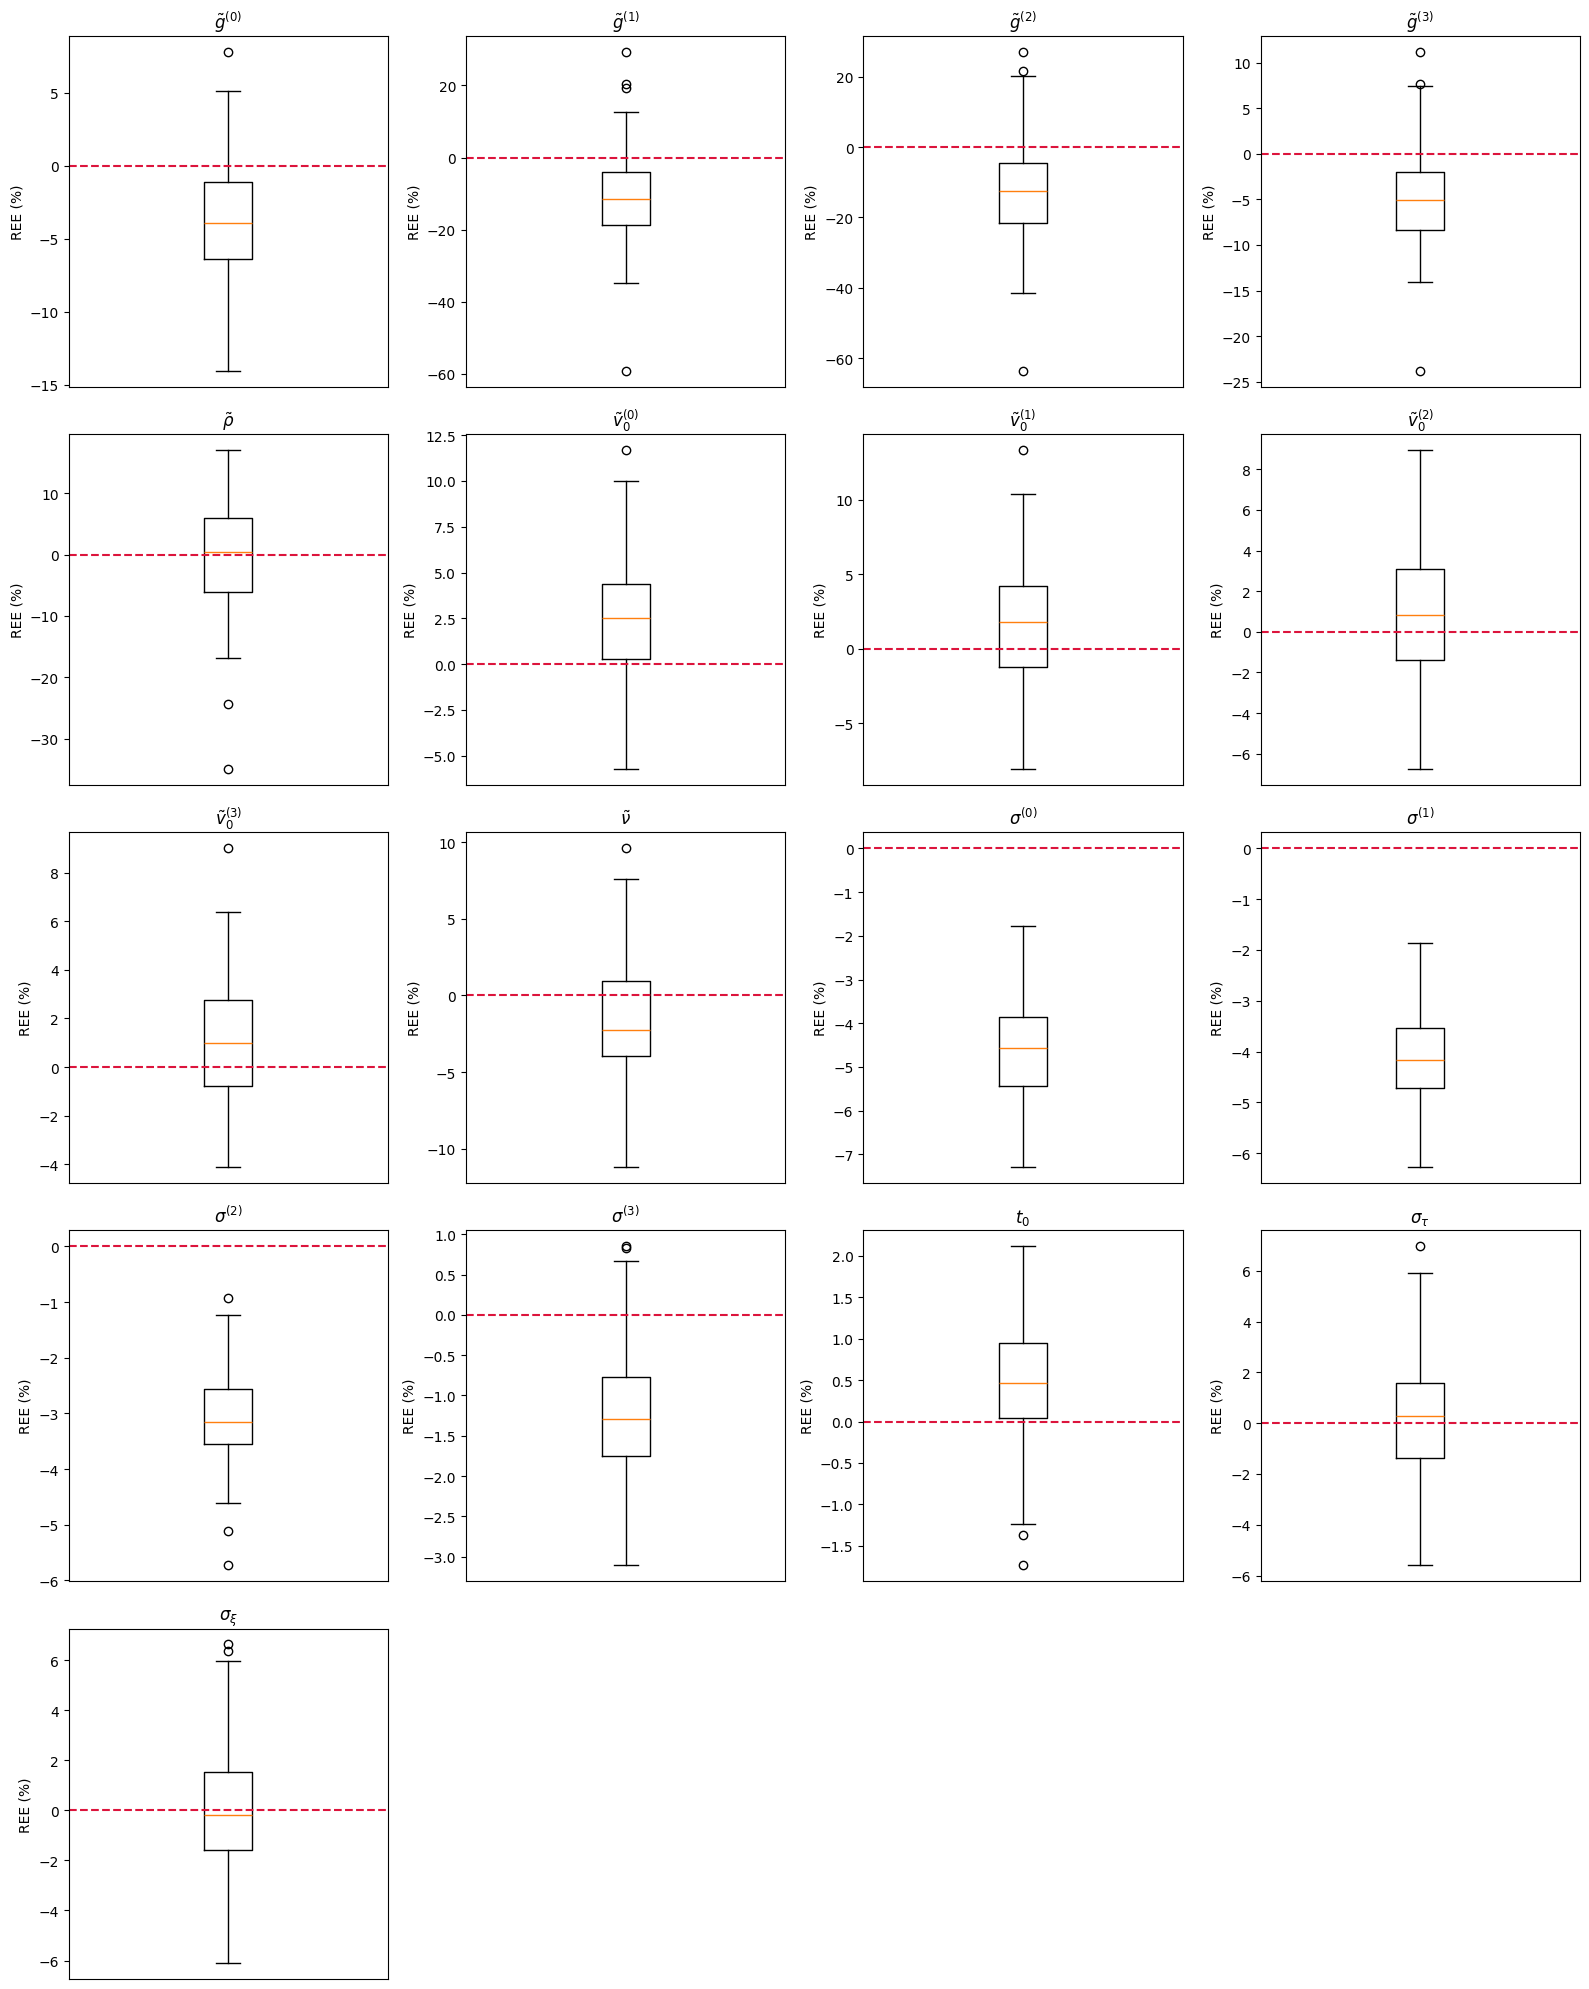

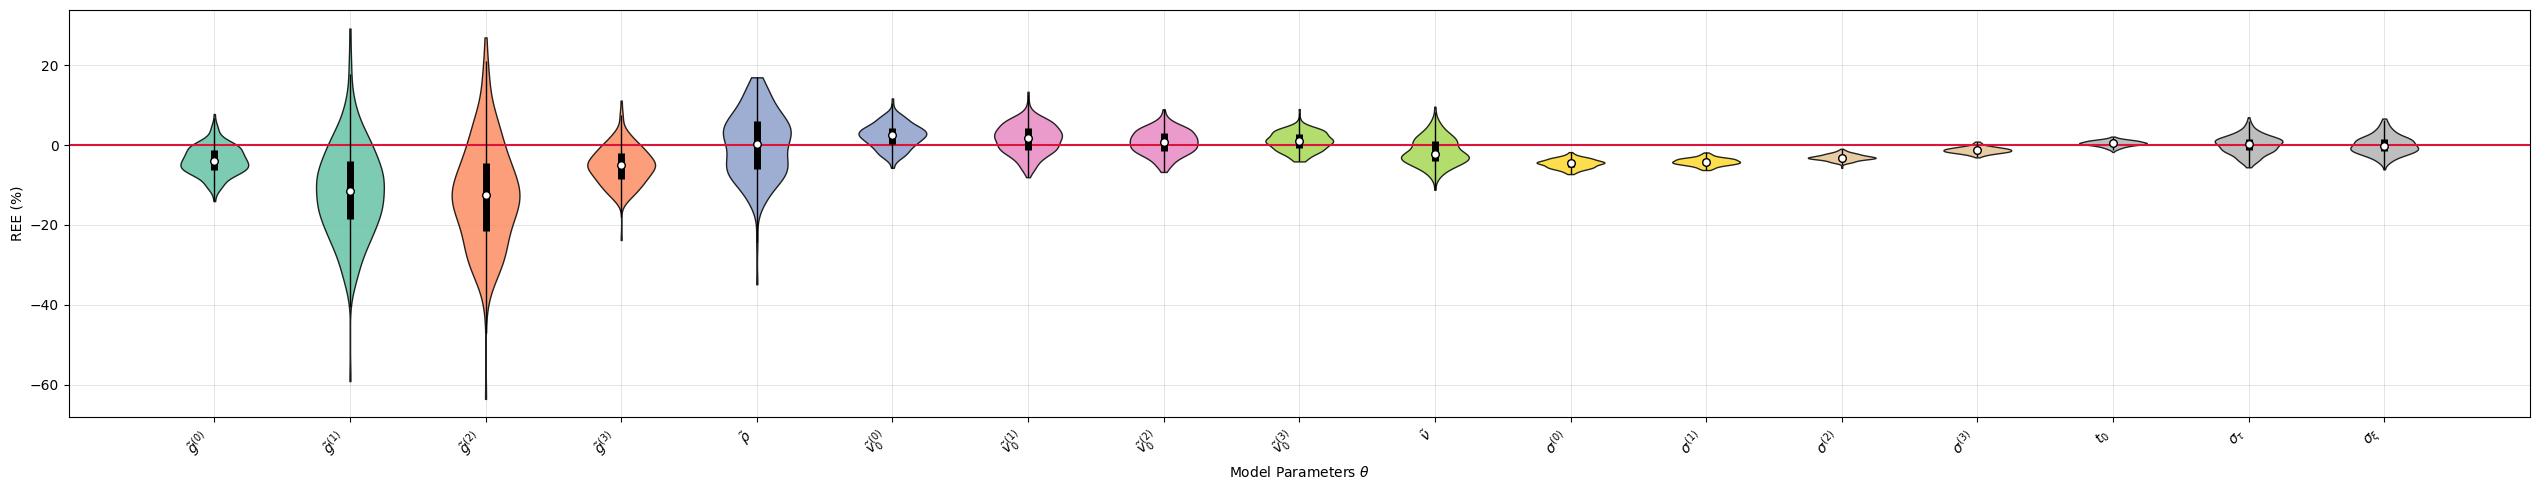

In [53]:
def sanitize_plot_label(label):
    if not isinstance(label, str):
        return label
    if label.startswith("$") and label.endswith("$"):
        return label
    if label.startswith("$") and "$ (" in label and label.endswith(")"):
        math_part, suffix = label.split("$ (", 1)
        idx = suffix[:-1]
        return f"{math_part}^{{({idx})}}$"
    return label


if ree_dict:
    n_params = len(ree_dict)
    ncols = min(4, n_params)
    nrows = (n_params + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for ax, (label, ree_vals) in zip(axes, ree_dict.items()):
        safe_label = sanitize_plot_label(label)
        ax.boxplot([ree_vals], vert=True)
        ax.axhline(0, color="crimson", linestyle="--", lw=1.5)
        ax.set_ylabel("REE (%)")
        ax.set_title(safe_label)
        ax.set_xticks([])

    for ax in axes[n_params:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    # --- Second figure: vertical violin plot, all parameters, same scale ---
    all_labels = [sanitize_plot_label(label) for label in ree_dict.keys()]
    all_data = [ree_dict[label] for label in all_labels]
    n_params = len(all_labels)

    colors = plt.cm.Set2(np.linspace(0, 1, n_params))

    fig2, ax2 = plt.subplots(figsize=(max(1.5 * n_params, 6), 5))

    parts = ax2.violinplot(
        all_data,
        positions=range(n_params),
        vert=True,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor("black")
        pc.set_linewidth(1)
        pc.set_alpha(0.85)

    # overlay mini box-plot + median dot
    for i, data in enumerate(all_data):
        q1, med, q3 = np.percentile(data, [25, 50, 75])
        iqr = q3 - q1
        whisker_lo = max(np.min(data), q1 - 1.5 * iqr)
        whisker_hi = min(np.max(data), q3 + 1.5 * iqr)

        # thick bar for IQR
        ax2.vlines(i, q1, q3, color="black", linewidth=5, zorder=3)
        # thin line for whiskers
        ax2.vlines(i, whisker_lo, whisker_hi, color="black", linewidth=1, zorder=3)
        # white dot for median
        ax2.scatter(i, med, color="white", edgecolor="black", s=30, zorder=4)

    ax2.axhline(0, color="crimson", linewidth=1.5, zorder=2)
    ax2.set_xticks(range(n_params))
    ax2.set_xticklabels(all_labels, rotation=45, ha="right")
    ax2.set_xlabel(r"Model Parameters $\theta$")
    ax2.set_ylabel("REE (%)")
    ax2.grid(True, axis="both", linestyle="-", linewidth=0.4, alpha=0.6)
    ax2.set_axisbelow(True)
    #ax2.set_ylim(bottom=min(-110, min(np.min(data) for data in all_data)), top=max(60, max(np.max(data) for data in all_data))) 

    plt.tight_layout()
    plt.show()

## Random effects: ICC 

The estimation of the random effects is assessed using the **intraclass correlation**
between the personalised values and the true values used for simulation.

We use ICC(3,1) — two-way mixed-effects model, single rater, absolute agreement:

$$ICC(3,1) = \frac{MS_B - MS_E}{MS_B + (k-1)\,MS_E}, \quad k=2$$

For reference, the Pearson correlation (which measures association but not agreement) is also reported.

x var       y var       IP                               ICC(3,1)       Pearson r
---------------------------------------------------------------------------
true_ips    est_ips     log-acceleration           0.988 +/- 0.004  0.989 +/- 0.004
true_ips    est_ips     time-shift                 0.995 +/- 0.002  0.995 +/- 0.002
true_ips    est_ips     space shift [0]            0.987 +/- 0.006  0.992 +/- 0.003
true_ips    est_ips     space shift [1]            0.989 +/- 0.003  0.990 +/- 0.003
true_ips    est_ips     space shift [2]            0.990 +/- 0.003  0.991 +/- 0.003
true_ips    est_ips     space shift [3]            0.987 +/- 0.003  0.988 +/- 0.003
true_ips    est_ips     survival shift [0]         0.965 +/- 0.027  0.978 +/- 0.013


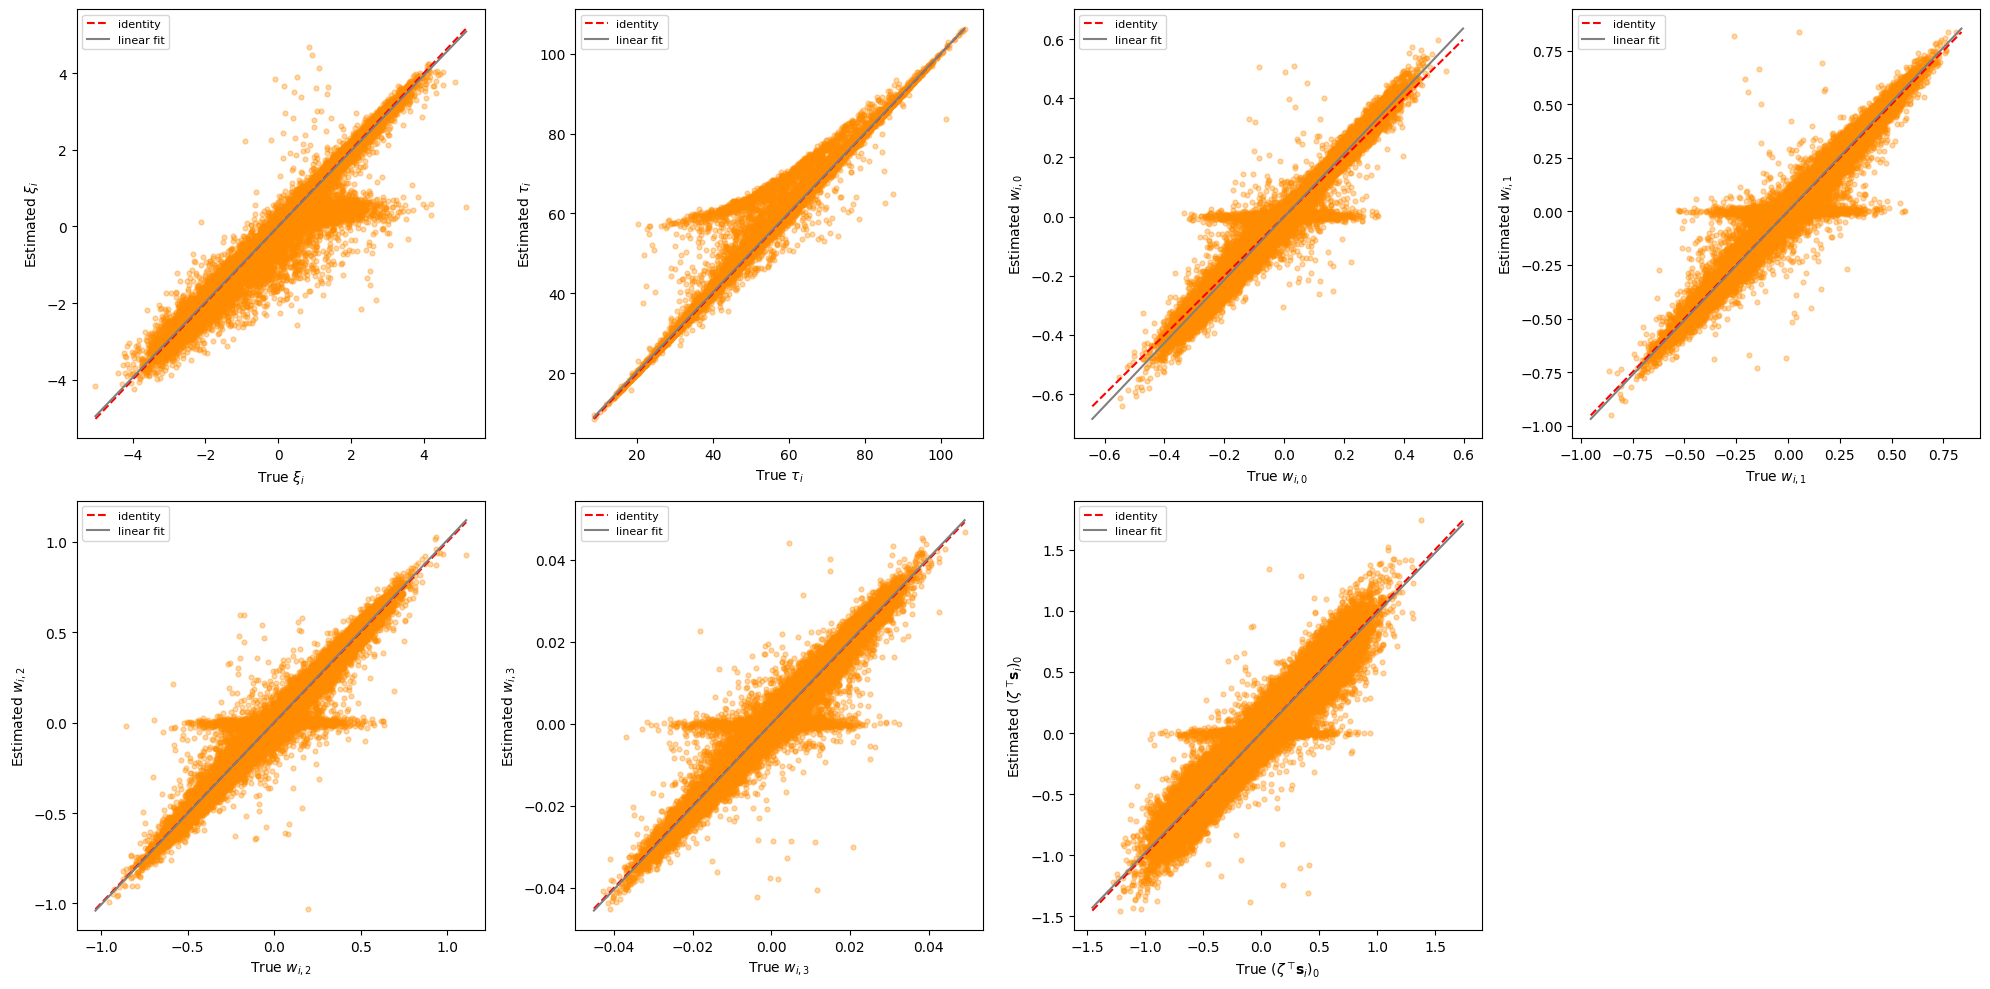

ref_ips     est_ips     log-acceleration           0.998 +/- 0.001  0.999 +/- 0.001
ref_ips     est_ips     time-shift                 0.999 +/- 0.001  0.999 +/- 0.001
ref_ips     est_ips     space shift [0]            0.994 +/- 0.006  1.000 +/- 0.000
ref_ips     est_ips     space shift [1]            0.998 +/- 0.001  1.000 +/- 0.000
ref_ips     est_ips     space shift [2]            0.999 +/- 0.001  1.000 +/- 0.000
ref_ips     est_ips     space shift [3]            0.998 +/- 0.002  0.999 +/- 0.001
ref_ips     est_ips     survival shift [0]         0.975 +/- 0.026  0.989 +/- 0.013


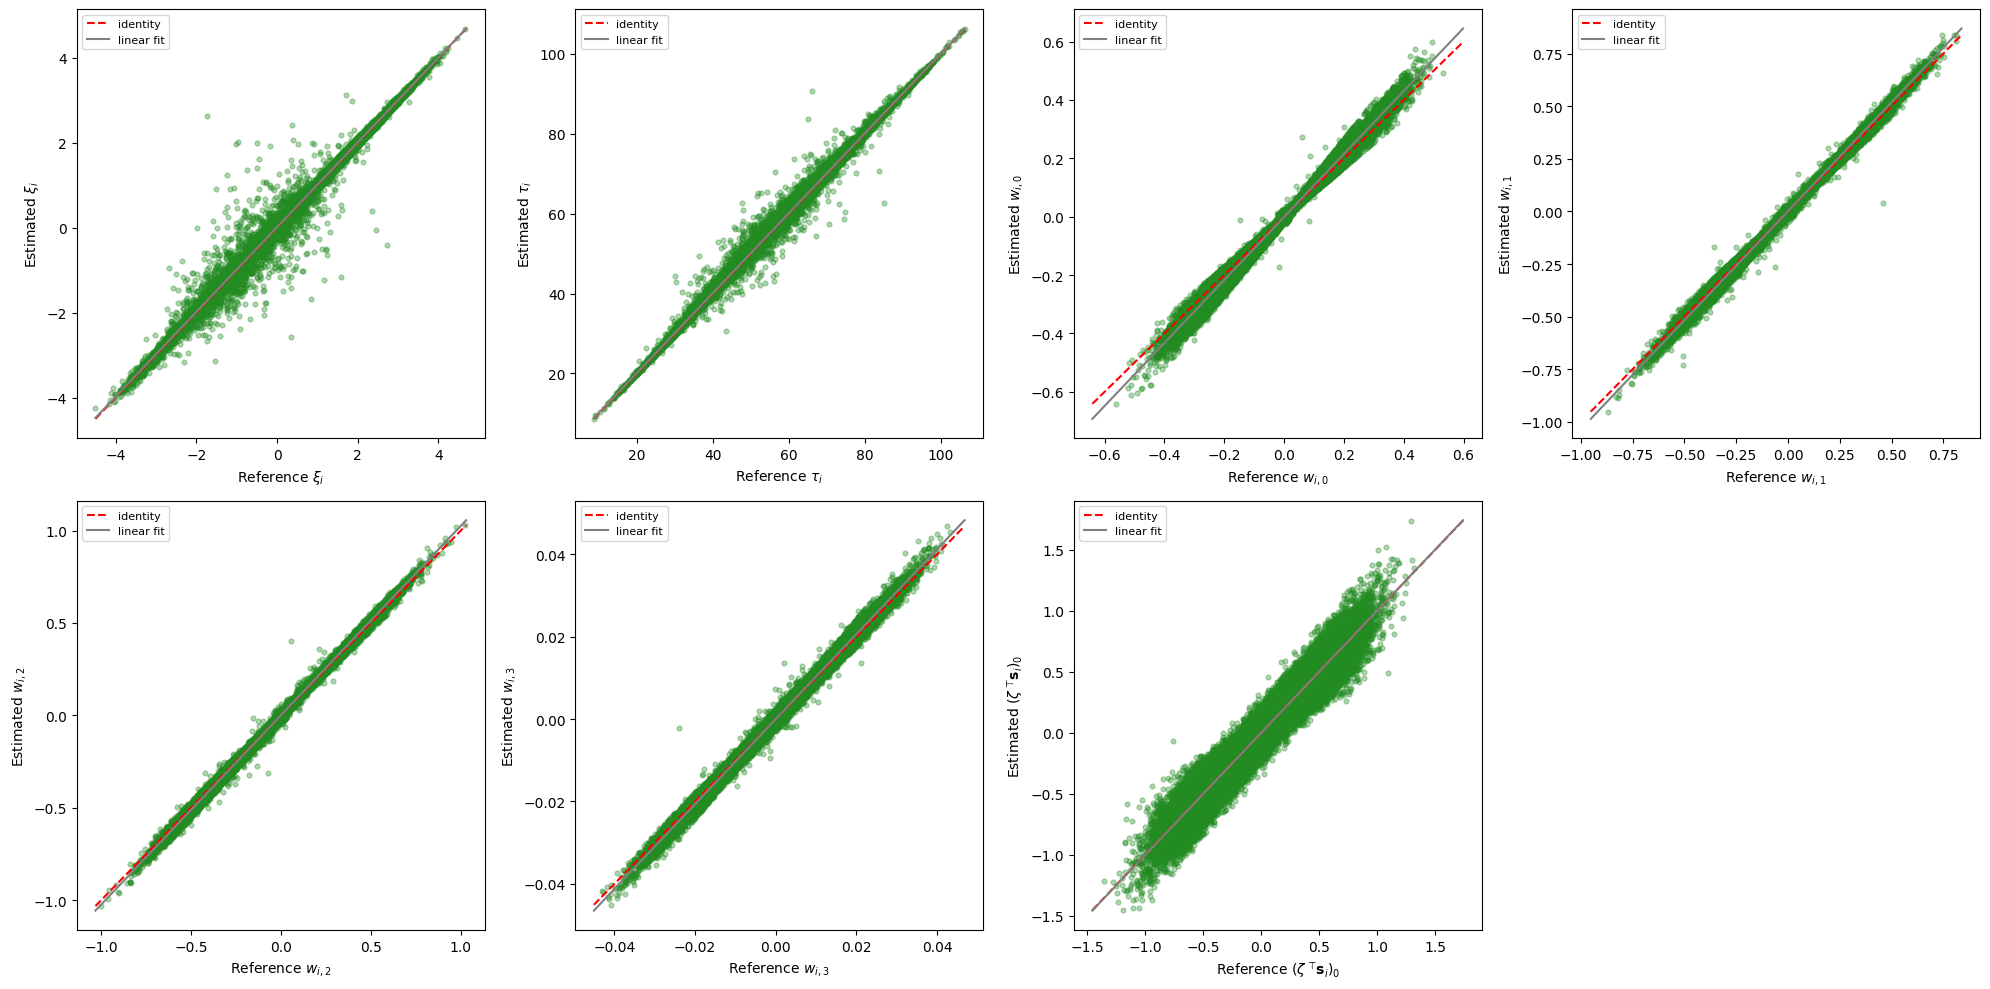

true_ips    ref_ips     log-acceleration           0.989 +/- 0.004  0.989 +/- 0.004
true_ips    ref_ips     time-shift                 0.996 +/- 0.002  0.996 +/- 0.002
true_ips    ref_ips     space shift [0]            0.992 +/- 0.003  0.992 +/- 0.003
true_ips    ref_ips     space shift [1]            0.990 +/- 0.003  0.990 +/- 0.003
true_ips    ref_ips     space shift [2]            0.991 +/- 0.003  0.991 +/- 0.003
true_ips    ref_ips     space shift [3]            0.989 +/- 0.003  0.989 +/- 0.003
true_ips    ref_ips     survival shift [0]         0.989 +/- 0.003  0.989 +/- 0.003


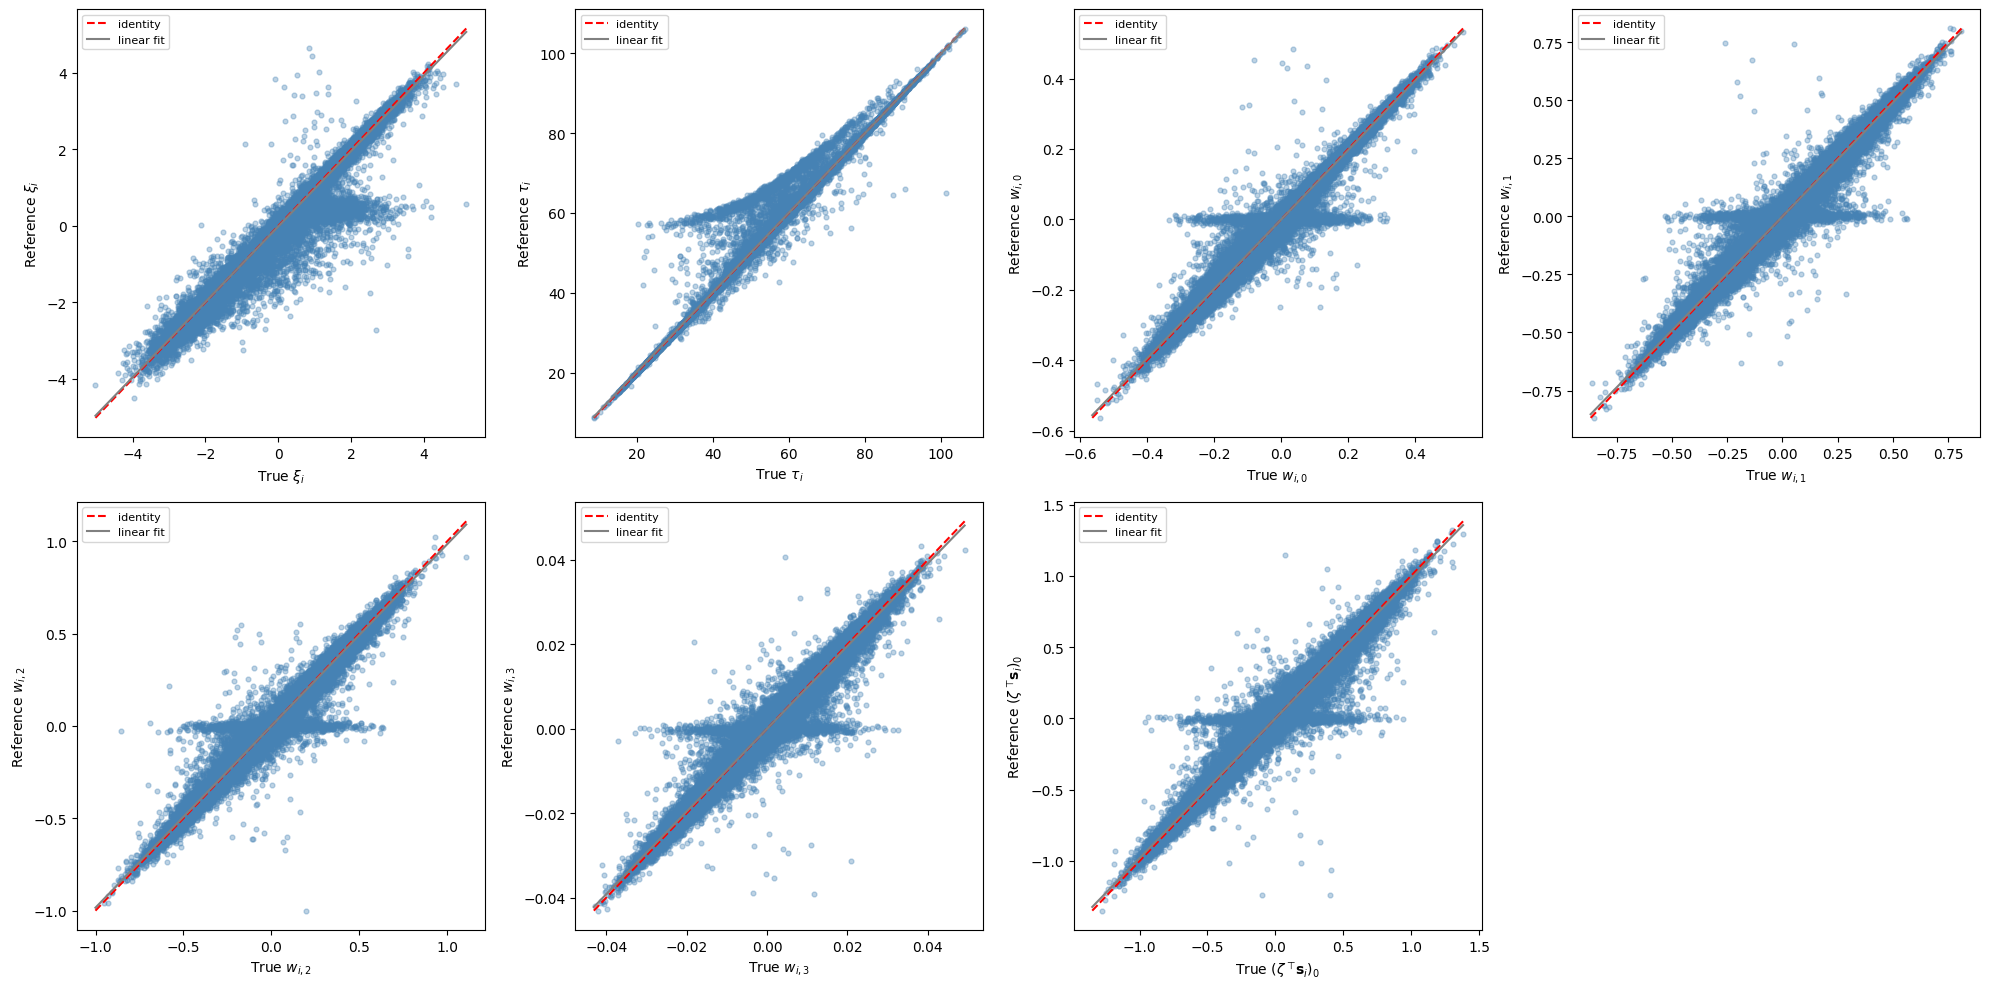

In [54]:
def icc_3_1(y_true, y_hat):
    """ICC(3,1) — two-way mixed-effects, k=2 raters, absolute agreement."""
    y_true = np.asarray(y_true, dtype=float)
    y_hat  = np.asarray(y_hat,  dtype=float)
    n = len(y_true)
    if n < 3:
        return float("nan")
    k = 2
    y = np.stack([y_true, y_hat], axis=1)
    grand_mean = y.mean()
    row_means  = y.mean(axis=1)
    ss_b = k * np.sum((row_means - grand_mean) ** 2)
    ss_e = np.sum((y - row_means[:, None]) ** 2)
    ms_b = ss_b / (n - 1)
    ms_e = ss_e / (n * (k - 1))
    return float((ms_b - ms_e) / (ms_b + (k - 1) * ms_e))


# ── Detect source columns from the stored individual parameters ───────────────
_sample = next((df for df in results["true_ips"] if df is not None), None)
source_cols = sorted([c for c in (_sample.columns if _sample is not None else []) if c.startswith("sources_")])
K = len(source_cols)


def _param_matrix(param_dict, key, K):
    if key not in param_dict:
        return None
    arr = np.asarray(param_dict[key], dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.shape[0] != K:
        arr = arr.T
    return arr


def _mixing_matrix_from_params(param_dict, K):
    if K == 0 or param_dict is None:
        return None
    if "mixing_matrix" in param_dict:
        return _param_matrix(param_dict, "mixing_matrix", K)
    tmp_model = JointModel(
        name="tmp_projection",
        nb_events=NB_EVENTS,
        dimension=ref_model.dimension,
        source_dimension=ref_model.source_dimension,
        obs_models=obs_model_name,
    )
    tmp_model.load_parameters(param_dict)
    return tmp_model.state["mixing_matrix"].detach().cpu().numpy().copy()


def _project_sources(ip_df, source_cols, mixing_matrix, zeta):
    if ip_df is None or not source_cols:
        return ip_df
    S = ip_df[source_cols].to_numpy(dtype=float)
    extra = {}
    if mixing_matrix is not None:
        W = S @ mixing_matrix
        for j in range(W.shape[1]):
            extra[f"__w_{j}__"] = W[:, j]
    if zeta is not None:
        SV = S @ zeta
        for j in range(SV.shape[1]):
            extra[f"__sv_{j}__"] = SV[:, j]
    if not extra:
        return ip_df
    return pd.concat([ip_df, pd.DataFrame(extra, index=ip_df.index)], axis=1)


# ── Build augmented IP DataFrames ─────────────────────────────────────────────
mixing_true = _mixing_matrix_from_params(theta_true, K) if K > 0 else None
zeta_true   = _param_matrix(theta_true, "zeta_mean",     K) if K > 0 else None

true_aug, ref_aug, est_aug = [], [], []
for t, r, e, p in zip(results["true_ips"], results["ref_ips"], results["est_ips"], results["pop_params"]):
    mixing_m = _mixing_matrix_from_params(p, K) if K > 0 else None
    zeta_m   = _param_matrix(p, "zeta_mean",     K) if K > 0 else None
    true_aug.append(_project_sources(t, source_cols, mixing_true, zeta_true))
    ref_aug.append( _project_sources(r, source_cols, mixing_true, zeta_true))
    est_aug.append( _project_sources(e, source_cols, mixing_m,    zeta_m))

valid_pairs         = [(t, e) for t, e in zip(true_aug, est_aug)  if t is not None and e is not None]
valid_ref_pairs     = [(t, r) for t, r in zip(true_aug, ref_aug)  if t is not None and r is not None]
valid_ref_est_pairs = [(r, e) for r, e in zip(ref_aug,  est_aug)  if r is not None and e is not None]

# ── Column list ───────────────────────────────────────────────────────────────
ip_cols  = ["xi", "tau"]
ip_latex = [r"$\xi_{i}$", r"$\tau_{i}$"]
ip_descs = ["log-acceleration", "time-shift"]

if mixing_true is not None:
    for j in range(mixing_true.shape[1]):
        ip_cols.append(f"__w_{j}__")
        ip_latex.append(rf"$w_{{i,{j}}}$")
        ip_descs.append(f"space shift [{j}]")

if zeta_true is not None:
    for j in range(zeta_true.shape[1]):
        ip_cols.append(f"__sv_{j}__")
        ip_latex.append(rf"$(\zeta^\top\!\mathbf{{s}}_i)_{{{j}}}$")
        ip_descs.append(f"survival shift [{j}]")

label_map = {
    "true_ips": "True",
    "ref_ips":  "Reference",
    "est_ips":  "Estimated",
}

comparisons = [
    ("true_ips", "est_ips", valid_pairs,         "darkorange"),
    ("ref_ips",  "est_ips", valid_ref_est_pairs,  "forestgreen"),
    ("true_ips", "ref_ips", valid_ref_pairs,      "steelblue"),
]

MAX_COLS = 4

if not any(pairs for _, _, pairs, _ in comparisons):
    print("No valid personalisation results — ICC cannot be computed.")
else:
    print(f"{'x var':10s}  {'y var':10s}  {'IP':25s}  {'ICC(3,1)':>14s}  {'Pearson r':>14s}")
    print("-" * 75)

    for x_var, y_var, pairs, cmp_color in comparisons:
        if not pairs:
            continue

        n_plots = len(ip_cols)
        ncols = min(n_plots, MAX_COLS)
        nrows = math.ceil(n_plots / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows),
                                 squeeze=False)
        axes_flat = axes.flatten()

        for col_idx, (col, col_ltx, col_desc) in enumerate(zip(ip_cols, ip_latex, ip_descs)):
            ax = axes_flat[col_idx]
            icc_vals, r_vals, all_x, all_y = [], [], [], []

            for x_df, y_df in pairs:
                if col not in x_df.columns or col not in y_df.columns:
                    continue
                common = x_df.index.astype(str).intersection(y_df.index.astype(str))
                if len(common) < 3:
                    continue
                xv = x_df.loc[x_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                yv = y_df.loc[y_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                all_x.append(xv)
                all_y.append(yv)
                icc_vals.append(icc_3_1(xv, yv))
                if np.std(xv) > 0 and np.std(yv) > 0:
                    r_vals.append(pearsonr(xv, yv)[0])

            if not all_x:
                ax.set_visible(False)
                continue

            ax_x = np.concatenate(all_x)
            ax_y = np.concatenate(all_y)
            lo = min(ax_x.min(), ax_y.min())
            hi = max(ax_x.max(), ax_y.max())

            ax.scatter(ax_x, ax_y, alpha=0.35, s=12, color=cmp_color)
            ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="identity")
            slope, intercept = np.polyfit(ax_x, ax_y, 1)
            ax.plot([lo, hi], [slope * lo + intercept, slope * hi + intercept],
                    color="grey", lw=1.5, label="linear fit")
            ax.set_xlabel(f"{label_map[x_var]} {col_ltx}")
            ax.set_ylabel(f"{label_map[y_var]} {col_ltx}")
            ax.legend(fontsize=8)

            icc_m = np.nanmean(icc_vals)
            icc_s = np.nanstd(icc_vals)
            r_m   = np.nanmean(r_vals) if r_vals else float("nan")
            r_s   = np.nanstd(r_vals)  if r_vals else float("nan")
            print(f"{x_var:10s}  {y_var:10s}  {col_desc:25s}  {icc_m:.3f} +/- {icc_s:.3f}  {r_m:.3f} +/- {r_s:.3f}")

        # Hide any leftover (empty) subplot cells
        for idx in range(n_plots, nrows * ncols):
            axes_flat[idx].set_visible(False)

        #plt.suptitle(f"{label_map[x_var]} vs {label_map[y_var]}", fontsize=12)
        plt.tight_layout()
        plt.show()

## Random effects: Bland-Altman

The Bland-Altman plot is the standard complement to ICC for method-comparison studies.
It plots the **difference** $\hat\theta_i - \theta_i^{true}$ against the **mean**
$\frac{\hat\theta_i + \theta_i^{true}}{2}$, pooled across all $M$ simulations.

Key quantities shown:
- **Bias** (mean difference, solid line): systematic over- or under-estimation
- **Limits of agreement** $\pm 1.96\,\text{SD}$ (dashed lines): range that captures ~95 % of individual differences

x var       y var       IP                               Bias     LoA lower     LoA upper
---------------------------------------------------------------------------
true_ips    est_ips     log-acceleration              -0.0025       -0.3242       +0.3192
true_ips    est_ips     time-shift                    +0.2385       -1.9937       +2.4707
true_ips    est_ips     space shift [0]               -0.0010       -0.0417       +0.0396
true_ips    est_ips     space shift [1]               +0.0009       -0.0564       +0.0581
true_ips    est_ips     space shift [2]               +0.0011       -0.0599       +0.0621
true_ips    est_ips     space shift [3]               -0.0000       -0.0033       +0.0033
true_ips    est_ips     survival shift [0]            -0.0010       -0.1603       +0.1583


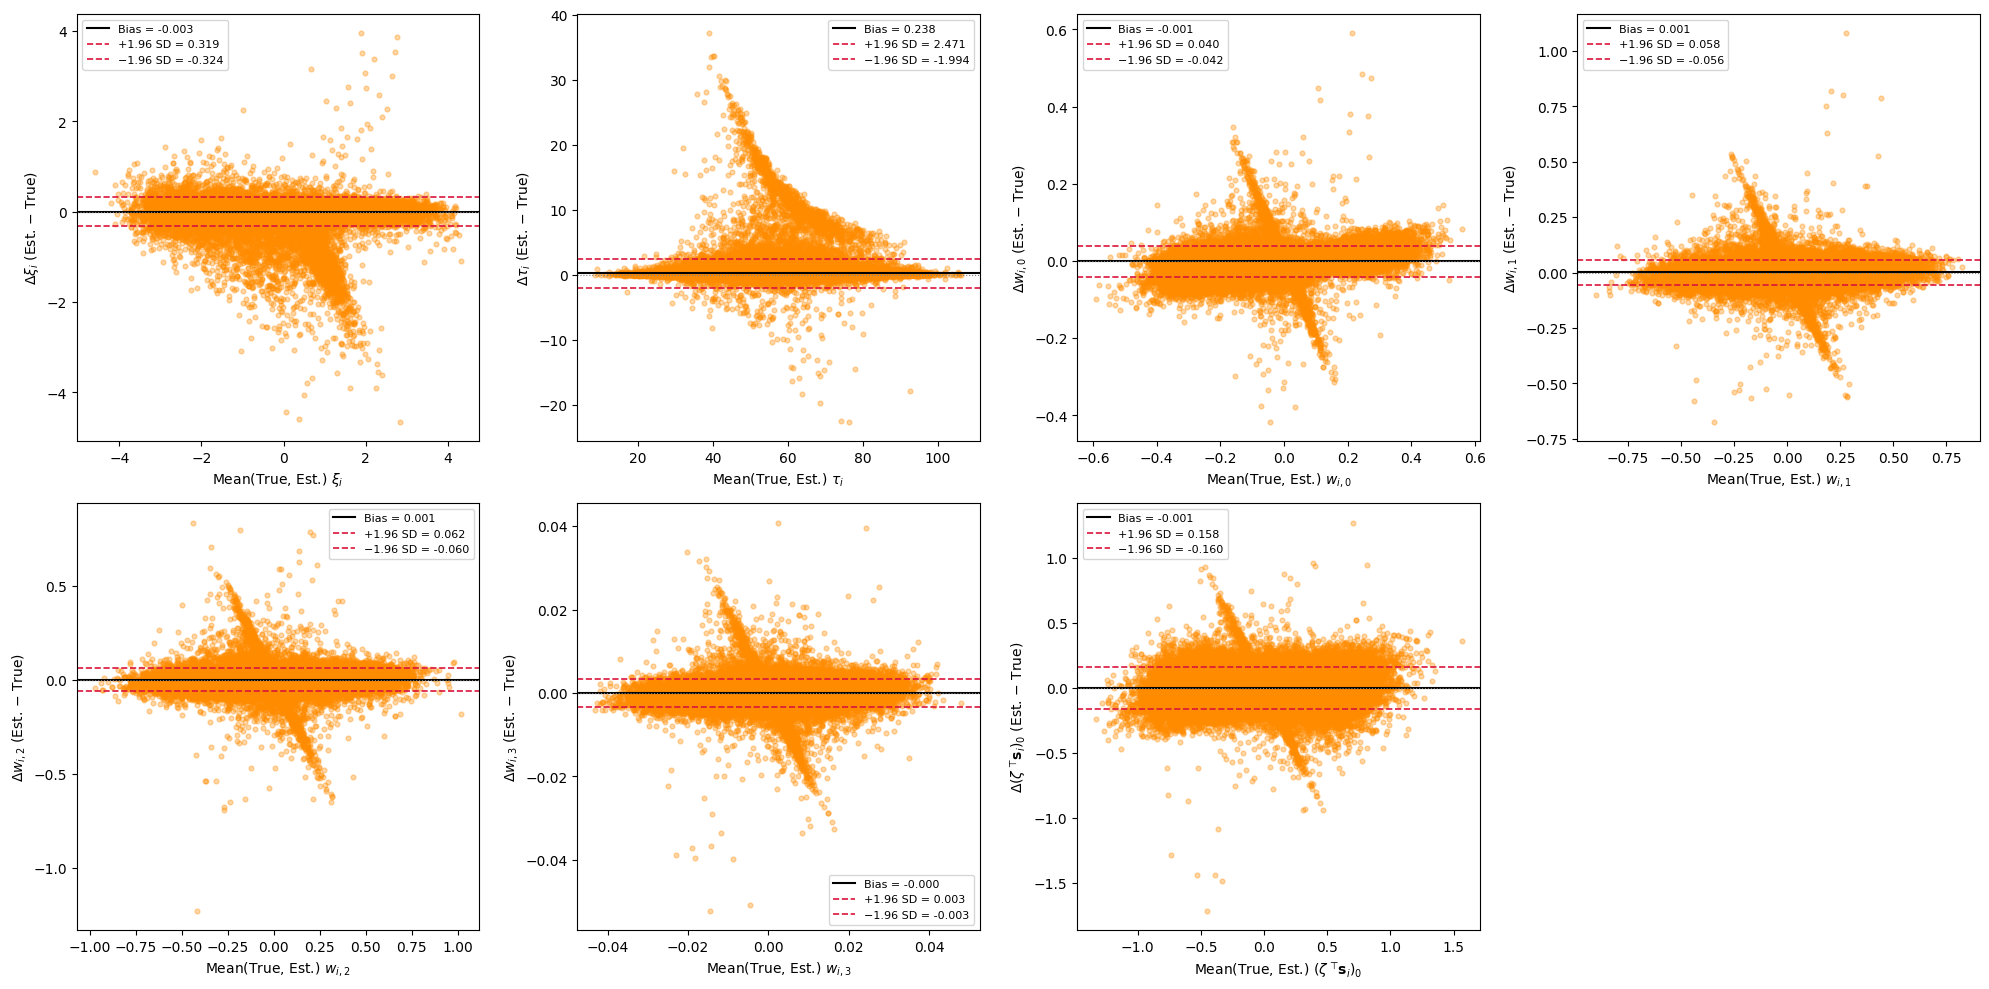

ref_ips     est_ips     log-acceleration              +0.0143       -0.1141       +0.1426
ref_ips     est_ips     time-shift                    +0.1504       -0.7049       +1.0057
ref_ips     est_ips     space shift [0]               -0.0010       -0.0286       +0.0267
ref_ips     est_ips     space shift [1]               +0.0008       -0.0221       +0.0236
ref_ips     est_ips     space shift [2]               +0.0010       -0.0197       +0.0217
ref_ips     est_ips     space shift [3]               -0.0000       -0.0014       +0.0014
ref_ips     est_ips     survival shift [0]            -0.0009       -0.1338       +0.1321


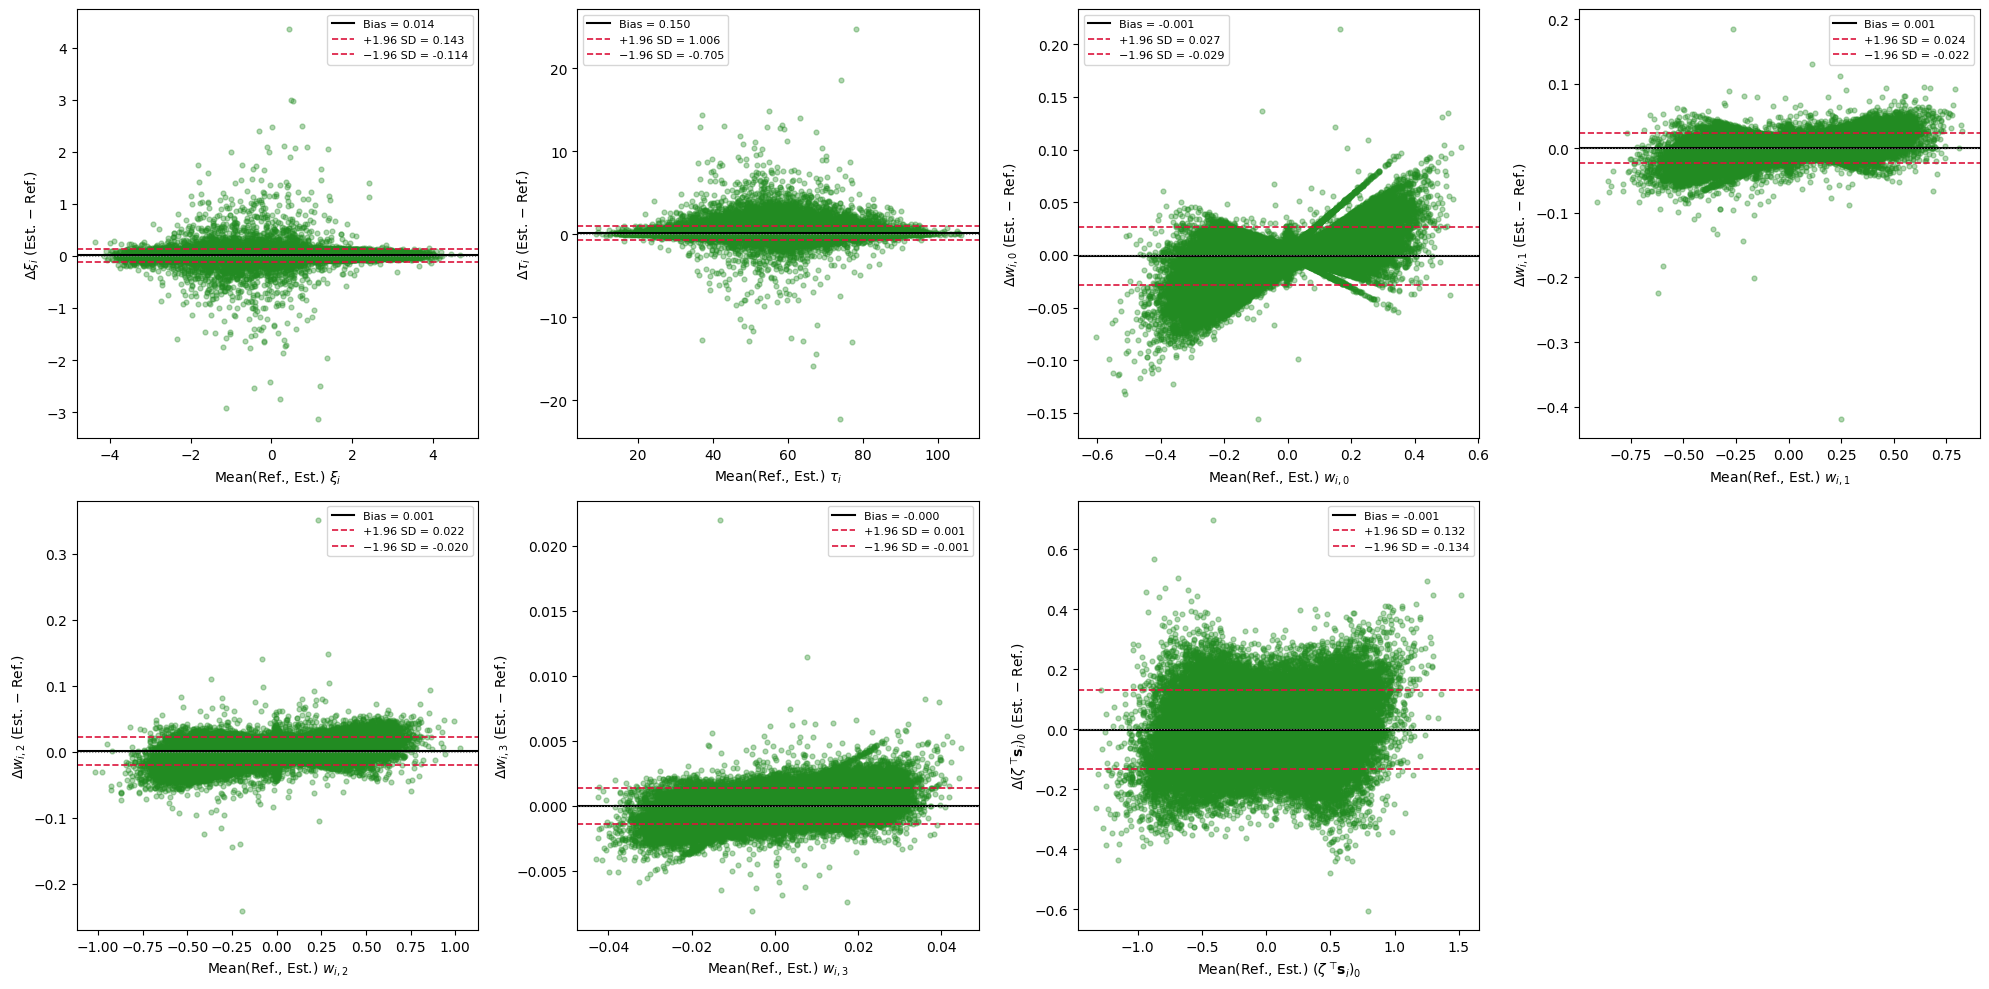

true_ips    ref_ips     log-acceleration              -0.0168       -0.3312       +0.2977
true_ips    ref_ips     time-shift                    +0.0881       -2.0398       +2.2160
true_ips    ref_ips     space shift [0]               -0.0001       -0.0300       +0.0299
true_ips    ref_ips     space shift [1]               +0.0001       -0.0527       +0.0529
true_ips    ref_ips     space shift [2]               +0.0001       -0.0575       +0.0577
true_ips    ref_ips     space shift [3]               -0.0000       -0.0030       +0.0030
true_ips    ref_ips     survival shift [0]            -0.0001       -0.0881       +0.0879


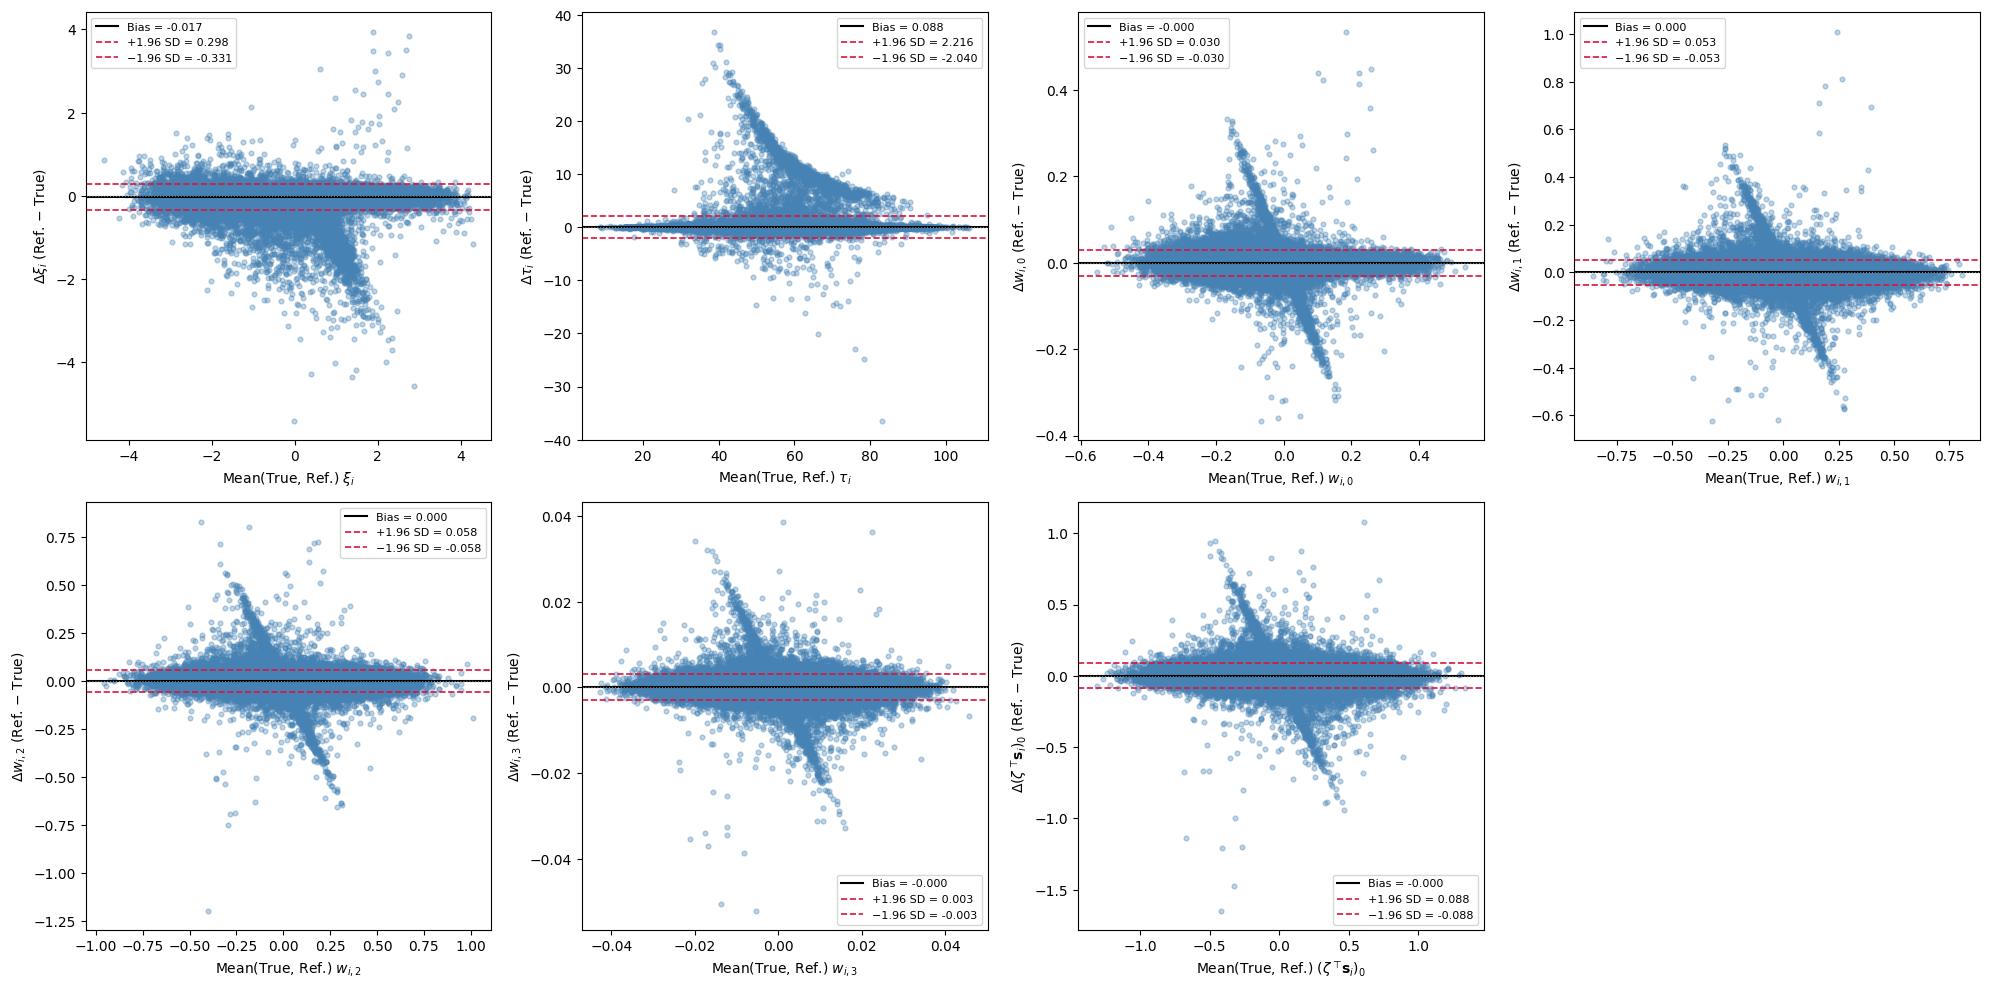

In [55]:
if not any([valid_pairs, valid_ref_pairs, valid_ref_est_pairs]):
    print("No valid personalisation results — Bland-Altman cannot be computed.")
else:
    short_label = {
        "true_ips": "True",
        "ref_ips":  "Ref.",
        "est_ips":  "Est.",
    }

    # Reuse ip_cols / ip_latex / ip_descs and comparisons defined in the ICC cell
    comparisons_ba = [
        ("true_ips", "est_ips", valid_pairs,         "darkorange"),
        ("ref_ips",  "est_ips", valid_ref_est_pairs,  "forestgreen"),
        ("true_ips", "ref_ips", valid_ref_pairs,      "steelblue"),
    ]

    MAX_COLS = 4

    print(f"{'x var':10s}  {'y var':10s}  {'IP':25s}  {'Bias':>10s}  {'LoA lower':>12s}  {'LoA upper':>12s}")
    print("-" * 75)

    for x_var, y_var, pairs, cmp_color in comparisons_ba:
        if not pairs:
            continue

        n_plots = len(ip_cols)
        ncols = min(n_plots, MAX_COLS)
        nrows = math.ceil(n_plots / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows),
                                 squeeze=False)
        axes_flat = axes.flatten()

        for col_idx, (col, col_ltx, col_desc) in enumerate(zip(ip_cols, ip_latex, ip_descs)):
            ax = axes_flat[col_idx]
            all_mean, all_diff = [], []

            for x_df, y_df in pairs:
                if col not in x_df.columns or col not in y_df.columns:
                    continue
                common = x_df.index.astype(str).intersection(y_df.index.astype(str))
                if len(common) < 3:
                    continue
                xv = x_df.loc[x_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                yv = y_df.loc[y_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                all_mean.append((xv + yv) / 2.0)
                all_diff.append(yv - xv)

            if not all_mean:
                ax.set_visible(False)
                continue

            means  = np.concatenate(all_mean)
            diffs  = np.concatenate(all_diff)
            bias   = float(diffs.mean())
            sd     = float(diffs.std(ddof=1))
            loa_lo = bias - 1.96 * sd
            loa_hi = bias + 1.96 * sd

            xl = short_label[x_var]
            yl = short_label[y_var]

            ax.scatter(means, diffs, alpha=0.35, s=12, color=cmp_color)
            ax.axhline(bias,   color="black",   lw=1.5, linestyle="-",  label=f"Bias = {bias:.3f}")
            ax.axhline(loa_hi, color="crimson", lw=1.2, linestyle="--", label=f"+1.96 SD = {loa_hi:.3f}")
            ax.axhline(loa_lo, color="crimson", lw=1.2, linestyle="--", label=f"\u22121.96 SD = {loa_lo:.3f}")
            ax.axhline(0, color="grey", lw=0.8, linestyle=":")
            ax.set_xlabel(f"Mean({xl}, {yl}) {col_ltx}")
            ax.set_ylabel(f"\u0394{col_ltx} ({yl} \u2212 {xl})")
            ax.legend(fontsize=8)

            print(f"{x_var:10s}  {y_var:10s}  {col_desc:25s}  {bias:+10.4f}  {loa_lo:+12.4f}  {loa_hi:+12.4f}")

        # Hide any leftover (empty) subplot cells
        for idx in range(n_plots, nrows * ncols):
            axes_flat[idx].set_visible(False)

        #plt.suptitle(f"Bland-Altman: {short_label[x_var]} vs {short_label[y_var]}", fontsize=12)
        plt.tight_layout()
        plt.show()

## Example simulated trajectories

Longitudinal feature trajectories for a handful of patients drawn from one simulated dataset.
Time is expressed **relative to each patient's individual time-shift** $\tau_i$, so all trajectories are centred around the same disease reference point (dotted black line at 0).

Each plot element:
- **Smooth curve** — the true noiseless latent trajectory $f(t;\,\theta,\,\xi_i,\tau_i)$, a monotonically increasing logistic S-curve
- **Dots** — the actual simulated observations, each drawn independently from $\text{Beta}(\alpha_{ij}, \beta_{ij})$ centred on the latent value; scatter around the curve reflects the measurement noise ($\hat\sigma \approx 0.39$, fitted on the PULSE dataset)
- **Solid vertical line** — observed event time $T_i - \tau_i$ (patient experienced the event); no visits are recorded after this point
- **Dashed vertical line** — censored event time (patient did not experience the event within the follow-up window)



Simulate with `joint_simulate` took: 5.24s


,ID,TIME,EVENT_TIME,EVENT_BOOL,ALSFRS_R_BULBAR,ALSFRS_R_FINE_MOTOR,ALSFRS_R_GROSS_MOTOR,ALSFRS_R_TOTAL
0,0,77.65,81.844749,0,1.873131e-15,0.040376,0.132342,0.017574
1,0,77.91,81.844749,0,9.601510e-15,0.198019,0.202086,0.154069
2,0,78.17,81.844749,0,6.032203e-08,0.222168,0.168802,0.187077
3,0,78.39,81.844749,0,7.393268e-02,0.182295,0.273377,0.155903
4,0,78.64,81.844749,0,3.598288e-02,0.315572,0.317944,0.157662
...,...,...,...,...,...,...,...,...
83,4,69.41,70.421029,1,9.985971e-01,0.379882,0.897675,0.640110
84,4,69.71,70.421029,1,9.999952e-01,0.529217,0.991980,0.810201
85,4,69.92,70.421029,1,1.000000e+00,0.570635,0.900320,0.796016
86,4,70.19,70.421029,1,1.000000e+00,0.789264,0.999117,0.842447


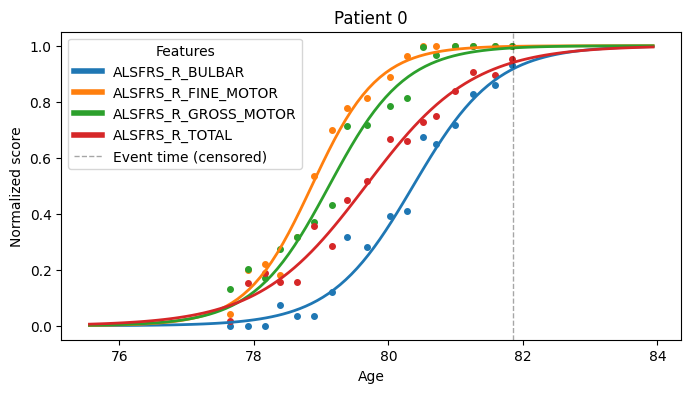

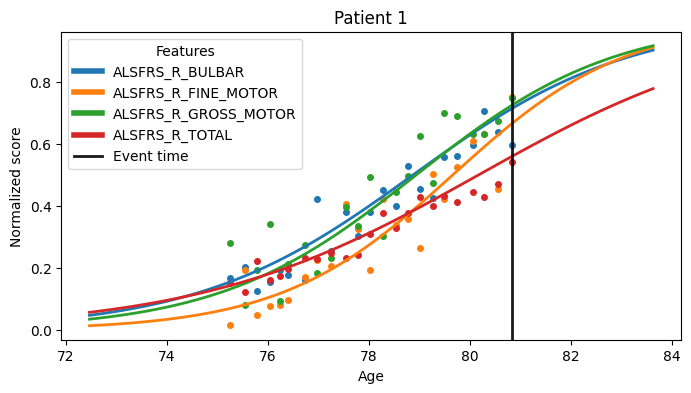

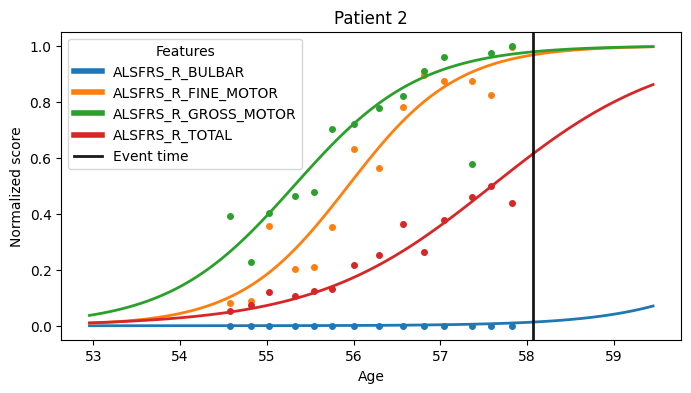

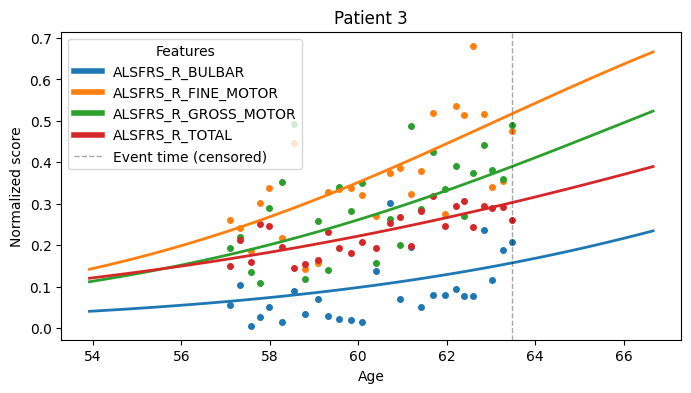

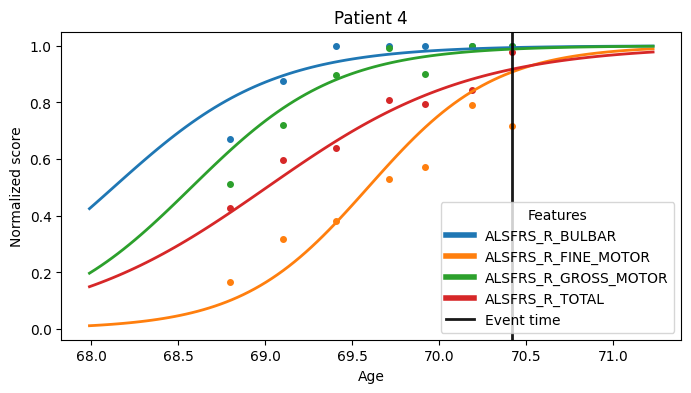

In [56]:
np.random.seed(12)
torch.manual_seed(12)

ex_result = ref_model.simulate(
    algorithm="joint_simulate",
    features=FEATURES,
    visit_parameters=visit_params,
)
df_ex = ex_result.data.to_dataframe()
ip_ex = ex_result.individual_parameters  # DataFrame with xi, tau, ...

evt_time_col = ex_result.data.event_time_name
evt_bool_col = ex_result.data.event_bool_name

from leaspy.io.logs.visualization.plotting import Plotting

ip_ex_named = ip_ex.copy()
ip_ex_named.index.name = "ID"

plotter = Plotting(ref_model)

N_SHOW = 5
shown_ids = df_ex["ID"].unique()[:N_SHOW]
N_FEATURES = 4

display(df_ex[df_ex["ID"].isin(shown_ids)][["ID", "TIME", evt_time_col, evt_bool_col] + FEATURES[:N_FEATURES]])

for pid in shown_ids:
    ax = plotter.patient_trajectories(
        data=ex_result.data,
        individual_parameters=ip_ex_named,
        patients_idx=[pid],
        features=FEATURES[:N_FEATURES],
    )
    ax.set_title(f"Patient {pid}")
    plt.show()